## Data Collection & Dataset Splitting

### Objectives
* Setup Kaggle authentication and download the official Cherry Leaves dataset from Kaggle.
* Inspect and clean dataset by removing non-image files.
* Split dataset randomly into **Train (70%)**, **Validation (10%)**, and **Test (20%)** sets.
* Plot and save the image distribution across splits to verify class balance.

### Inputs
* `kaggle.json` API authentication file located in project root.
* Kaggle Dataset: `codeinstitute/cherry-leaves`

### Outputs
* `inputs/cherry_leaves/` directory containing `train`, `validation`, and `test` folders split into `healthy` and `powdery_mildew`.
* `outputs/v1/class_distribution.png` visual plot.

In [16]:
import os
import glob
import random
import shutil
import zipfile
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

# 1. Resolve Project Root Directory
current_dir = os.getcwd()
if os.path.basename(current_dir) == 'jupyter_notebooks':
    PROJECT_DIR = os.path.abspath(os.path.join(current_dir, '..'))
else:
    PROJECT_DIR = current_dir

# 2. Configure Kaggle Credentials Path
os.environ['KAGGLE_CONFIG_DIR'] = PROJECT_DIR

# 3. Define Project Subdirectories
INPUTS_DIR = os.path.join(PROJECT_DIR, 'inputs')
RAW_DATA_DIR = os.path.join(INPUTS_DIR, 'raw_data')
SPLIT_DATA_DIR = os.path.join(INPUTS_DIR, 'cherry_leaves')
OUTPUTS_DIR = os.path.join(PROJECT_DIR, 'outputs', 'v1')

# 4. Create Directories at Project Root
os.makedirs(RAW_DATA_DIR, exist_ok=True)
os.makedirs(SPLIT_DATA_DIR, exist_ok=True)
os.makedirs(OUTPUTS_DIR, exist_ok=True)

print(f"Project Root: {PROJECT_DIR}")
print(f"Outputs Directory: {OUTPUTS_DIR}")

Project Root: d:\books\code\code-institut\PROJECTS\cherry tree leaves
Outputs Directory: d:\books\code\code-institut\PROJECTS\cherry tree leaves\outputs\v1


In [18]:
import os

# If current directory is 'jupyter_notebooks', navigate one level up to project root
current_dir = os.getcwd()
if os.path.basename(current_dir) == 'jupyter_notebooks':
    PROJECT_DIR = os.path.abspath(os.path.join(current_dir, '..'))
else:
    PROJECT_DIR = current_dir

INPUTS_DIR = os.path.join(PROJECT_DIR, 'inputs')
RAW_DATA_DIR = os.path.join(INPUTS_DIR, 'raw_data')
SPLIT_DATA_DIR = os.path.join(INPUTS_DIR, 'cherry_leaves')
OUTPUTS_DIR = os.path.join(PROJECT_DIR, 'outputs', 'v1')

print(f"Project Root Directory: {PROJECT_DIR}")

Project Root Directory: d:\books\code\code-institut\PROJECTS\cherry tree leaves


In [9]:
%pip install kaggle


   ------ ---------------------------------  2/13 [tqdm]
   ------ ---------------------------------  2/13 [tqdm]
   ------ ---------------------------------  2/13 [tqdm]
   --------- ------------------------------  3/13 [pyyaml]
   ------------ ---------------------------  4/13 [python-slugify]
   --------------- ------------------------  5/13 [python-dotenv]
   ------------------ ---------------------  6/13 [fastjsonschema]
   --------------------- ------------------  7/13 [mdit-py-plugins]
   --------------------- ------------------  7/13 [mdit-py-plugins]
   --------------------- ------------------  7/13 [mdit-py-plugins]
   --------------------- ------------------  7/13 [mdit-py-plugins]
   --------------------- ------------------  7/13 [mdit-py-plugins]
   --------------------- ------------------  7/13 [mdit-py-plugins]
   ------------------------ ---------------  8/13 [kagglesdk]
   ------------------------ ---------------  8/13 [kagglesdk]
   ------------------------ ---------

In [19]:
# Download Kaggle Dataset
import kaggle

dataset_name = "codeinstitute/cherry-leaves"
print(f"Downloading dataset '{dataset_name}'...")

kaggle.api.dataset_download_files(dataset_name, path=RAW_DATA_DIR, unzip=True)
print("Download and extraction complete.")

Dataset URL: https://www.kaggle.com/datasets/codeinstitute/cherry-leaves
Download and extraction complete.


In [20]:
# Verify and remove non-image files
valid_extensions = ('.png', '.jpg', '.jpeg', '.PNG', '.JPG', '.JPEG')
removed_count = 0

for root, _, files in os.walk(RAW_DATA_DIR):
    for file in files:
        file_path = os.path.join(root, file)
        if not file.endswith(valid_extensions):
            os.remove(file_path)
            removed_count += 1
            print(f"Removed non-image file: {file_path}")

print(f"Data cleaning complete. Total invalid files removed: {removed_count}")

Data cleaning complete. Total invalid files removed: 0


Category 'healthy': 2104 total -> Train: 1472, Val: 210, Test: 422
Category 'powdery_mildew': 2104 total -> Train: 1472, Val: 210, Test: 422

Dataset Distribution Summary:
        Split           Label  Count
0       Train         Healthy   1472
1  Validation         Healthy    210
2        Test         Healthy    422
3       Train  Powdery Mildew   1472
4  Validation  Powdery Mildew    210
5        Test  Powdery Mildew    422


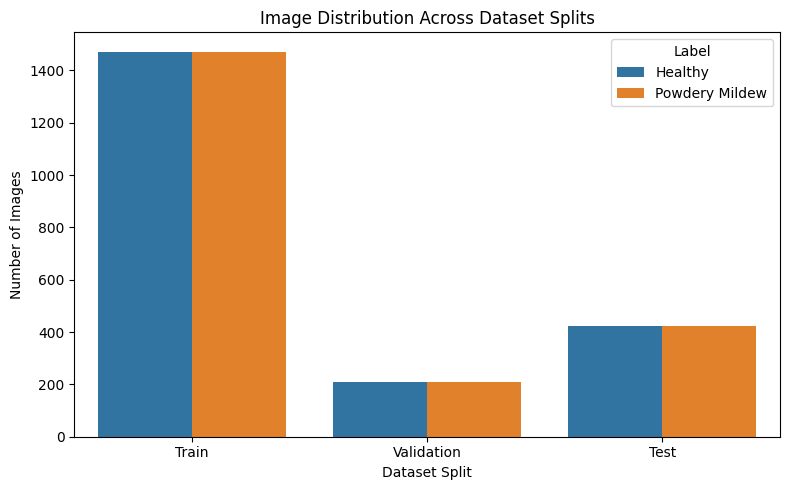

Distribution plot saved to: d:\books\code\code-institut\PROJECTS\cherry tree leaves\outputs\v1\class_distribution.png


In [23]:
# Cell 6: Split Dataset and Save Distribution Plot

def split_dataset(raw_dir, target_dir, train_ratio=0.70, val_ratio=0.10, test_ratio=0.20, seed=42):
    """
    Splits images from raw directory into train, validation, and test folders.
    """
    valid_extensions = ('.png', '.jpg', '.jpeg', '.PNG', '.JPG', '.JPEG')
    assert np.isclose(train_ratio + val_ratio + test_ratio, 1.0), "Ratios must sum to 1.0"
    random.seed(seed)
    
    categories = [d for d in os.listdir(raw_dir) if os.path.isdir(os.path.join(raw_dir, d))]
    df_list = []
    
    for category in categories:
        category_raw_path = os.path.join(raw_dir, category)
        images = [f for f in os.listdir(category_raw_path) if f.endswith(valid_extensions)]
        random.shuffle(images)
        
        n_total = len(images)
        n_train = int(n_total * train_ratio)
        n_val = int(n_total * val_ratio)
        
        splits = {
            'Train': images[:n_train],
            'Validation': images[n_train:n_train + n_val],
            'Test': images[n_train + n_val:]
        }
        
        for split_name, split_files in splits.items():
            split_folder = os.path.join(target_dir, split_name.lower(), category)
            os.makedirs(split_folder, exist_ok=True)
            
            for file_name in split_files:
                src_path = os.path.join(category_raw_path, file_name)
                dst_path = os.path.join(split_folder, file_name)
                shutil.copyfile(src_path, dst_path)
            
            df_list.append({
                'Split': split_name,
                'Label': category.replace('_', ' ').title(),
                'Count': len(split_files)
            })
            
        print(f"Category '{category}': {n_total} total -> Train: {len(splits['Train'])}, Val: {len(splits['Validation'])}, Test: {len(splits['Test'])}")

    return pd.DataFrame(df_list)

# 1. Execute Dataset Splitting
df_distribution = split_dataset(
    raw_dir=os.path.join(RAW_DATA_DIR, 'cherry-leaves'),
    target_dir=SPLIT_DATA_DIR
)

# 2. Display Distribution DataFrame
print("\nDataset Distribution Summary:")
print(df_distribution)

# 3. Plot and Save Class Distribution Visualization
plt.figure(figsize=(8, 5))
sns.barplot(data=df_distribution, x='Split', y='Count', hue='Label')
plt.title('Image Distribution Across Dataset Splits')
plt.ylabel('Number of Images')
plt.xlabel('Dataset Split')
plt.tight_layout()

# Save plot to outputs/v1/
plot_path = os.path.join(OUTPUTS_DIR, 'class_distribution.png')
plt.savefig(plot_path, dpi=300)
plt.show()
print(f"Distribution plot saved to: {plot_path}")